# Notebook 2 — Normalização BIO e experimento de validação

Fase final de validação do projeto de **Argumentation Mining em Community Notes BR**.
Comparamos duas estratégias de extração de spans argumentativos — **E1** (regras
simbólicas, spaCy) e **E2** (LLM) — entre si e contra um **gold humano**, sobre o
dataset consolidado pelo Notebook 1 (`notebook_preparacao_v2.ipynb`).

Cada nota recebe spans de quatro tipos: **CLAIM** (alegação refutada), **EVIDÊNCIA**
(o fato que sustenta a checagem), **FONTE** (a quem se atribui) e **QUALIFICADOR**
(modulação epistêmica).

## Como ler este notebook

O notebook tem duas partes:

- **Parte I — Camada BIO.** Carrega o dataset (E1 v2.1, com a ingestão de FONTE corrigida),
  projeta os spans de **E1**, **E2** (LLM via API), **E2b** (mesma estratégia com modelo
  aberto local) e **humano** para a representação **BIO** token a token, mantendo os spans
  com offsets como fonte primária.
- **Parte II — Experimento (proposta §4).** Mede acordo entre estratégias (§4.1), métricas
  operacionais (§4.3), caracteriza o corpus (§4.4), fidelidade ao tweet (§4.2), avalia
  contra o gold humano em desenho **multi-gold e em duas leituras** (§4.5), faz a leitura
  token-level (seqeval, com *cross-check* da biblioteca) e as análises complementares da
  §4.6. Fecha salvando um **dataset final** para publicação.

Cada seção traz um bloco **"Pergunta / Como ler"** antes do código e uma **"Leitura"**
logo depois, com a conclusão daquele resultado.

> **Gold humano:** duas anotações independentes (`data/gold/`) + **consenso adjudicado**
> (`apps/adjudicador`, com trilha de decisões auditável). O κ inter-anotador é calculado
> sempre a partir das anotações originais, independentemente do gold final.

## Decisões metodológicas

1. **Spans com offsets são a representação primária** — base das métricas de §4.
2. **BIO é uma camada derivada e determinística:** dado o texto, os offsets e o
   tokenizador, `B-TIPO` no primeiro token de um span, `I-TIPO` nos demais, `O` fora.
3. **Tokenizador único e fixo** (`spacy.lang.pt.Portuguese`): a mesma tokenização vale
   para E1, E2, E2b e humano, garantindo o alinhamento token a token.
4. **Política de conflito explícita** para sobreposição (só nas estratégias automáticas):
   por token, o span de maior interseção; empate → mais longo; novo empate → prioridade
   fixa de tipo. Os spans originais nunca são alterados.
5. **FONTE ancorada em URL é infraestrutura compartilhada**: a mesma regex a injeta nas
   estratégias automáticas e o app de anotação a pré-marcava no gold. Por isso toda
   avaliação contra gold sai em **duas leituras** — *completa* (compara sistemas) e
   *sem FONTE-URL* (compara o conteúdo decidido por modelos e humanos).
6. **Convenção de gold vazio declarada:** em notas onde o gold não marca nada, abster-se
   vale F1 = 1 (zeros são dado substantivo); a sensibilidade a essa convenção é reportada.

As colunas de span são listas aninhadas de offsets tipados; o dataset é lido e gravado
com `pyarrow`.

## Glossário de métricas

| Métrica | O que mede | Leitura |
|---|---|---|
| **F1 estrita** | match exato de offset **e** tipo | alto = fronteiras idênticas |
| **F1 relaxada** | overlap ≥ 50% **e** tipo | alto = concordância tolerante a fronteira |
| **κ char-level** | concordância por caractere, corrigida pelo acaso | Landis & Koch: <0.2 fraca · 0.2–0.4 regular · 0.4–0.6 moderada · >0.6 substancial |
| **κ por presença** | "ambos marcaram ≥1 span deste tipo?" | robusto à granularidade de fronteira |
| **seqeval (entity)** | P/R/F1 por entidade BIO (fronteira de token + tipo) | leitura token-level por tipo |


## 0. Dependências

In [1]:
!pip -q install gdown pandas pyarrow spacy scikit-learn tqdm matplotlib seqeval


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Registro do ambiente (reprodutibilidade)
import platform
import importlib.metadata as _md

def _v(pkg):
    try:
        return _md.version(pkg)
    except _md.PackageNotFoundError:
        return '(ausente)'

print('python', platform.python_version(), '|', platform.platform())
for _p in ['pandas', 'numpy', 'pyarrow', 'spacy', 'scikit-learn', 'seqeval', 'tqdm']:
    print(f'  {_p:<16} {_v(_p)}')

python 3.12.3 | Windows-11-10.0.22631-SP0
  pandas           2.2.2
  numpy            2.5.0
  pyarrow          24.0.0
  spacy            3.8.14
  scikit-learn     1.9.0
  seqeval          1.2.2
  tqdm             4.66.4


## 1. Configuração

Os IDs do Drive ficam aqui. **Para somar um anotador, basta adicionar o ID do JSON dele em `ANOTADOR_DRIVE_IDS` e re-rodar.**

In [3]:
from __future__ import annotations

import json
import math
import re
import urllib.request
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

# --- fontes de dados: preferimos os arquivos do PROPRIO REPOSITORIO ---
# Resolucao: caminho relativo (rodando dentro do repo) -> copia local ja baixada ->
# download do GitHub (raw). O Drive fica como fallback legado do dataset.
GITHUB_RAW = "https://raw.githubusercontent.com/rocdav/community-notes-br-argmining/main/"
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
FINAL_DATASET_PATH = OUT_DIR / "dataset_anotado_final_com_bio.parquet"

def resolver(relpath: str) -> Path:
    """Localiza um arquivo do repositorio; baixa do GitHub (raw) se preciso."""
    rel = Path(relpath)
    for cand in (Path("..") / rel, rel):
        if cand.exists():
            return cand
    dest = DATA_DIR / rel.name
    if not dest.exists():
        url = GITHUB_RAW + str(rel).replace("\\", "/")
        print(f"baixando {rel.name} do repositorio...")
        urllib.request.urlretrieve(url, dest)
    return dest

DATASET_RELPATH = "data/dataset_anotado_final.parquet"     # E1 v2.1 (ingestao corrigida)
DRIVE_FILE_ID = "1uOQa49x8XCPYrydKHCkP2XREA2CdP2Mj"        # fallback legado

# --- anotacao humana: arquivos versionados no repo ---
ANOTADORES = {
    "davi": "data/gold/anotacao_manual_davi-machado-da-rocha_2026-05-20.json",
    "alvaro": "data/gold/anotacao_manual_alvaro-barros_2026-07-02.json",
}
# Gold final = consenso adjudicado (apps/adjudicador). Com None, vale o fluxo legado
# (2 anotadores -> intersecao exata; 1 anotador -> anotacao unica).
CONSENSUS_JSON_RELPATH: str | None = "data/gold/anotacao_consenso_adjudicado_2026-07-02.json"

# --- E2b: reexecucao fiel da estrategia E2 com modelo aberto local (Ollama) ---
E2B_SWEEP_RELPATH: str | None = "apps/anotador-llm/output/e2_ollama_sweep.jsonl"

TEXT_COL_CANDIDATES = ("text", "note_text", "summary")
SPAN_SOURCES = {"e1": "e1_spans", "e2": "e2_spans", "e2b": "e2b_spans", "humano": "anotacao_humana_spans"}
LABELS = ["CLAIM", "EVIDENCIA", "FONTE", "QUALIFICADOR"]
ALLOWED_TYPES = set(LABELS)
LABEL_ALIASES = {
    "EVIDÊNCIA": "EVIDENCIA", "EVIDENCIA": "EVIDENCIA", "EVIDENCE": "EVIDENCIA",
    "SOURCE": "FONTE", "QUALIFIER": "QUALIFICADOR",
}
TYPE_PRIORITY = {"FONTE": 0, "QUALIFICADOR": 1, "CLAIM": 2, "EVIDENCIA": 3}

# FONTE-URL = infraestrutura compartilhada (regex dos dois lados da regua) — ver
# "Decisoes metodologicas". Usada para as duas leituras da avaliacao.
URL_RE = re.compile(r"https?://")

BIO_TOKENIZER = "spacy_pt_blank_v1"
BIO_PROJECTION_VERSION = "2.0.0"
CONFLICT_POLICY = "token_max_overlap_then_longest_then_type_priority"
print("Config OK.")

Config OK.


C:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento do dataset

Lido com `pyarrow`, que preserva as colunas de span aninhadas.

In [4]:
def _load_dataset():
    try:
        return resolver(DATASET_RELPATH)
    except Exception as exc:
        print(f"repo indisponivel ({exc}); fallback: Drive (dataset v2).")
        import gdown
        dest = DATA_DIR / "dataset_anotado_final.parquet"
        if not dest.exists():
            gdown.download(f"https://drive.google.com/uc?id={DRIVE_FILE_ID}", str(dest), quiet=False)
        return dest

df = pd.read_parquet(_load_dataset(), engine="pyarrow")
df["noteId"] = df["noteId"].astype(str)

TEXT_COL = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
if TEXT_COL is None:
    raise ValueError(f"Nenhuma coluna textual encontrada. Procurei: {TEXT_COL_CANDIDATES}")

def _n_spans(v):
    return len(v) if (v is not None and hasattr(v, "__len__")) else 0

n_e1 = int(df["e1_spans"].apply(_n_spans).gt(0).sum())
n_e2 = int(df["e2_spans"].apply(_n_spans).gt(0).sum())
ver = df["e1_version"].iloc[0] if "e1_version" in df.columns else "v2 (original)"
print("shape:", df.shape, "| coluna texto:", TEXT_COL, "| E1:", ver)
print(f"notas com spans E1: {n_e1} | E2: {n_e2}")
assert n_e1 > 0 and n_e2 > 0, "Spans E1/E2 nao carregados; leia o dataset com engine='pyarrow'."

# --- E2b: mesmo prompt/protocolo do E2, servido por modelo aberto local ---
if E2B_SWEEP_RELPATH:
    e2b_path = resolver(E2B_SWEEP_RELPATH)
    e2b_rows = [json.loads(l) for l in open(e2b_path, encoding="utf-8")]
    e2b_map = {str(r["noteId"]): [s for s in (r.get("e2_spans") or []) if s.get("start") is not None]
               for r in e2b_rows}
    e2b_ms_map = {str(r["noteId"]): r.get("e2_ms") for r in e2b_rows}
    df["e2b_spans"] = df["noteId"].map(lambda x: e2b_map.get(x))
    df["e2b_ms"] = df["noteId"].map(lambda x: e2b_ms_map.get(x))
    n_e2b = int(df["e2b_spans"].apply(_n_spans).gt(0).sum())
    E2B_MODEL = next((r.get("model") for r in e2b_rows if r.get("model")), "?")
    print(f"E2b carregado: {n_e2b} notas com spans | modelo: {E2B_MODEL}")
else:
    df["e2b_spans"] = None
    df["e2b_ms"] = None
    E2B_MODEL = None

shape: (1901, 24) | coluna texto: text | E1: v2.1_relocated_entities
notas com spans E1: 1566 | E2: 1413
E2b carregado: 1465 notas com spans | modelo: qwen3.6:35b (ollama)


### 2.1 Integridade dos spans

**Como ler:** as três fontes devem aparecer com `offsets_ruins = 0` (todos os spans caem
dentro do texto). O `humano` aparece **VAZIO** até o gold ser montado a partir do JSON do
anotador (§5).

In [5]:
def auditar(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for nome, col in SPAN_SOURCES.items():
        if col not in df.columns:
            rows.append({"fonte": nome, "coluna": col, "status": "AUSENTE"}); continue
        n = df[col].apply(_n_spans)
        tot = int(n.sum()); notas = int(n.gt(0).sum())
        ok = bad = 0
        for txt, spans in zip(df[TEXT_COL], df[col]):
            if not isinstance(txt, str): continue
            if spans is None or not hasattr(spans, "__len__") or len(spans) == 0: continue
            for s in spans:
                st, en = int(s["start"]), int(s["end"])
                if 0 <= st < en <= len(txt): ok += 1
                else: bad += 1
        rows.append({"fonte": nome, "coluna": col, "notas_com_spans": notas,
                     "spans": tot, "offsets_ok": ok, "offsets_ruins": bad,
                     "status": "OK" if tot > 0 else "VAZIO"})
    return pd.DataFrame(rows)

display(auditar(df))
if "is_meta" in df.columns:
    print("meta-notas:", int(df["is_meta"].sum()), f"({100*df['is_meta'].mean():.1f}%)")

,fonte,coluna,notas_com_spans,spans,offsets_ok,offsets_ruins,status
0,e1,e1_spans,1566,3789,3789,0,OK
1,e2,e2_spans,1413,4626,4626,0,OK
2,e2b,e2b_spans,1465,5036,5036,0,OK
3,humano,anotacao_humana_spans,0,0,0,0,VAZIO


meta-notas: 404 (21.3%)


## 3. Anotação humana

As duas anotações independentes e o **consenso adjudicado** são arquivos **versionados no
repositório** (`data/gold/`). O κ inter-anotador é calculado **sempre** a partir das duas
anotações originais; o gold final vem do consenso adjudicado quando disponível.

In [6]:
HUMAN_JSON_PATHS = {apelido: str(resolver(rel)) for apelido, rel in ANOTADORES.items()}
CONSENSUS_JSON_PATH = str(resolver(CONSENSUS_JSON_RELPATH)) if CONSENSUS_JSON_RELPATH else None
print("anotadores:", HUMAN_JSON_PATHS)
print("consenso adjudicado:", CONSENSUS_JSON_PATH or "(nenhum — fluxo legado)")

anotadores: {'davi': '..\\data\\gold\\anotacao_manual_davi-machado-da-rocha_2026-05-20.json', 'alvaro': '..\\data\\gold\\anotacao_manual_alvaro-barros_2026-07-02.json'}
consenso adjudicado: ..\data\gold\anotacao_consenso_adjudicado_2026-07-02.json


In [7]:
def _load_human_json(path: str) -> tuple[str, dict[str, list[dict]]]:
    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    nome = (payload.get("anotador") or {}).get("nome") or Path(path).stem
    spans = {}
    for nid, a in payload.get("anotacoes", {}).items():
        if isinstance(a, dict):
            spans[str(nid)] = [
                {"start": int(s["start"]), "end": int(s["end"]),
                 "type": LABEL_ALIASES.get(str(s["type"]).upper(), str(s["type"]).upper())}
                for s in (a.get("spans") or [])
            ]
    return nome, spans

humano_por_anotador: dict[str, dict[str, list[dict]]] = {}
for apelido, path in HUMAN_JSON_PATHS.items():
    nome, spans = _load_human_json(path)
    humano_por_anotador[apelido] = spans
    print(f"anotador '{apelido}' ({nome}): {len(spans)} notas, {sum(len(v) for v in spans.values())} spans")

anotador 'davi' (Davi Machado da Rocha): 60 notas, 101 spans
anotador 'alvaro' (Alvaro Barros): 60 notas, 217 spans


## 4. Definições — normalização de spans e métricas

Funções usadas em todo o notebook. As de métrica são idênticas às do Notebook 1.

In [8]:
def is_missing_value(v: Any) -> bool:
    if v is None or v is pd.NA: return True
    if isinstance(v, float) and math.isnan(v): return True
    return False

def to_builtin(v: Any) -> Any:
    return v.tolist() if hasattr(v, "tolist") else v

def coerce_spans(v: Any):
    v = to_builtin(v)
    if is_missing_value(v): return None
    if isinstance(v, str):
        s = v.strip()
        if not s or s.lower() in {"nan", "none", "null"}: return None
        v = json.loads(s)
    v = to_builtin(v)
    if isinstance(v, dict) and "spans" in v: v = v["spans"]
    if isinstance(v, tuple): v = list(v)
    if not isinstance(v, list): raise TypeError(f"spans nao e' lista: {type(v).__name__}")
    out = []
    for it in v:
        it = to_builtin(it)
        if it is None: continue
        if not isinstance(it, dict): raise TypeError(f"span nao e' dict: {type(it).__name__}")
        out.append(dict(it))
    return out

def normalize_type(raw) -> str:
    lab = LABEL_ALIASES.get(str(raw).strip().upper(), str(raw).strip().upper())
    if lab not in ALLOWED_TYPES: raise ValueError(f"Tipo invalido: {raw!r}")
    return lab

@dataclass(frozen=True)
class S:
    start: int; end: int; type: str

def _ov(a: S, b: S) -> int:
    return max(0, min(a.end, b.end) - max(a.start, b.start))

def f1_strict(gold, pred) -> float:
    g = {(s.start, s.end, s.type) for s in gold}; p = {(s.start, s.end, s.type) for s in pred}
    tp = len(g & p)
    if not tp: return 0.0 if (g or p) else 1.0
    P = tp / len(p); R = tp / len(g); return 2 * P * R / (P + R)

def f1_relaxed(gold, pred, mr: float = 0.5) -> float:
    mg, mp = set(), set()
    for i, a in enumerate(gold):
        for j, b in enumerate(pred):
            if a.type != b.type or j in mp: continue
            if _ov(a, b) / max(a.end - a.start, b.end - b.start, 1) >= mr:
                mg.add(i); mp.add(j); break
    tp = len(mg)
    if not tp: return 0.0 if (gold or pred) else 1.0
    P = tp / len(pred) if pred else 0.0; R = tp / len(gold) if gold else 0.0
    return 2 * P * R / (P + R) if (P + R) else 0.0

def _char_labels(text, spans):
    lab = ["O"] * len(text)
    for s in spans:
        for i in range(s.start, min(s.end, len(text))): lab[i] = s.type
    return lab

def cohen_kappa_chars(text, a, b) -> float:
    if not text: return 0.0
    la = _char_labels(text, a); lb = _char_labels(text, b); n = len(text)
    po = sum(1 for x, y in zip(la, lb) if x == y) / n
    cats = set(la) | set(lb)
    pe = sum((la.count(c) / n) * (lb.count(c) / n) for c in cats)
    return (po - pe) / (1 - pe) if pe < 1 else 1.0

def spans_from_cell(v):
    raw = coerce_spans(v)
    return [] if raw is None else [S(int(s["start"]), int(s["end"]),
            LABEL_ALIASES.get(str(s["type"]).upper(), str(s["type"]).upper())) for s in raw]
def is_url_fonte(text: str, s: "S") -> bool:
    return s.type == "FONTE" and bool(URL_RE.search(text[s.start:s.end]))

def sem_url_fonte(text: str, spans):
    """Remove FONTE ancorada em URL (infraestrutura compartilhada; ver decisoes 5)."""
    return [s for s in spans if not is_url_fonte(text, s)]

def cohen_kappa_chars_pooled(pairs) -> float:
    """kappa agregado: concatena os rotulos de caractere de todas as notas.
    pairs: iteravel de (text, spans_a, spans_b)."""
    la_all, lb_all = [], []
    for text, a, b in pairs:
        if not text:
            continue
        la_all.extend(_char_labels(text, a))
        lb_all.extend(_char_labels(text, b))
    n = len(la_all)
    if not n:
        return float("nan")
    po = sum(1 for x, y in zip(la_all, lb_all) if x == y) / n
    ca, cb = Counter(la_all), Counter(lb_all)
    pe = sum((ca[c] / n) * (cb[c] / n) for c in set(la_all) | set(lb_all))
    return (po - pe) / (1 - pe) if pe < 1 else 1.0

print("Definicoes OK.")

Definicoes OK.


## 5. Anotadores, κ inter-anotador e gold final

O **κ inter-anotador** é calculado sempre, a partir das duas anotações originais, em
**duas leituras**: *completa* e *sem FONTE-URL*. A segunda existe porque as URLs eram
**pré-marcadas** pelo app de anotação — e um dos exports as preservou enquanto o outro
não. São infraestrutura, não decisão de anotador; a leitura sem elas mede o acordo sobre o
conteúdo efetivamente decidido.

O **gold final** vem do consenso adjudicado (`apps/adjudicador`, com trilha de decisões
por span versionada no JSON) quando `CONSENSUS_JSON_RELPATH` está definido; sem ele, vale
o fluxo legado (interseção exata de 2 anotadores, ou anotador único). Os golds individuais
são preservados para a análise de sensibilidade da §4.5.

In [9]:
all_df_ids = set(df["noteId"].astype(str))
text_by_id = dict(zip(df["noteId"].astype(str), df[TEXT_COL]))

def _to_S(spans):
    return [S(int(s["start"]), int(s["end"]), normalize_type(s["type"])) for s in spans]

# --- kappa inter-anotador: SEMPRE, nas duas leituras ---
kappa_inter_df = None
apelidos = list(humano_por_anotador)
if len(apelidos) >= 2:
    A, B = humano_por_anotador[apelidos[0]], humano_por_anotador[apelidos[1]]
    notes = sorted((set(A) | set(B)) & all_df_ids)
    linhas = []
    for leitura, strip in [("completa", False), ("sem FONTE-URL", True)]:
        ks, pares = [], []
        for nid in notes:
            txt = text_by_id.get(nid) or ""
            if not txt:
                continue
            sa, sb = _to_S(A.get(nid, [])), _to_S(B.get(nid, []))
            if strip:
                sa, sb = sem_url_fonte(txt, sa), sem_url_fonte(txt, sb)
            ks.append(cohen_kappa_chars(txt, sa, sb))
            pares.append((txt, sa, sb))
        linhas.append({"leitura": leitura, "n_notas": len(ks),
                       "kappa_medio_por_nota": round(float(np.mean(ks)), 3),
                       "kappa_pooled": round(cohen_kappa_chars_pooled(pares), 3)})
    kappa_inter_df = pd.DataFrame(linhas)
    print(f"kappa inter-anotador ({apelidos[0]} x {apelidos[1]}):")
    display(kappa_inter_df)

# --- gold final ---
gold = {}; gold_label = None
if CONSENSUS_JSON_PATH:
    _nome_consenso, gold = _load_human_json(CONSENSUS_JSON_PATH)
    gold_label = "consenso_adjudicado"
    print(f"gold = consenso adjudicado ('{_nome_consenso}')")
elif len(apelidos) >= 2:
    # fluxo legado: intersecao exata (conservador); o fluxo atual e' o apps/adjudicador
    def _set(spans): return {(s["start"], s["end"], s["type"]) for s in spans}
    A, B = humano_por_anotador[apelidos[0]], humano_por_anotador[apelidos[1]]
    for nid in sorted((set(A) | set(B)) & all_df_ids):
        gold[nid] = [{"start": x[0], "end": x[1], "type": x[2]}
                     for x in sorted(_set(A.get(nid, [])) & _set(B.get(nid, [])))]
    gold_label = f"intersecao({apelidos[0]}+{apelidos[1]})"
elif apelidos:
    gold = dict(humano_por_anotador[apelidos[0]]); gold_label = apelidos[0]

# reguas para a sensibilidade da §4.5: cada anotador + o gold final
golds_sensibilidade = dict(humano_por_anotador)
golds_sensibilidade["consenso"] = gold

ids = df["noteId"].astype(str)
df["anotacao_humana_spans"] = ids.map(lambda x: gold.get(x))
df["anotacao_humana_anotador"] = ids.map(lambda x: gold_label if x in gold else None)
df["anotacao_humana_status"] = ids.map(lambda x: "selecionada_para_anotacao" if x in gold else "nao_anotada")
annotated_ids = sorted(nid for nid in gold if nid in all_df_ids)
gold_vazio = sum(1 for nid in annotated_ids if not gold[nid])
print(f"gold = {gold_label or '—'} | {len(annotated_ids)} notas ({gold_vazio} com gold vazio)")

kappa inter-anotador (davi x alvaro):


,leitura,n_notas,kappa_medio_por_nota,kappa_pooled
0,completa,60,0.334,0.242
1,sem FONTE-URL,60,0.632,0.650


gold = consenso adjudicado ('Consenso Davi Machado da Rocha + Alvaro Barros')


gold = consenso_adjudicado | 60 notas (11 com gold vazio)


## 6. Tokenização fixa

Uma vez por nota, reaproveitada por E1, E2 e humano. Trata artefatos de entidade HTML.

In [10]:
from spacy.lang.pt import Portuguese
nlp = Portuguese()
HTML_ENTITY_ARTIFACT = re.compile(r"&(?:quot|amp|lt|gt|apos);?|(?:quot|amp|lt|gt|apos);")

@dataclass(frozen=True)
class Token:
    text: str; start: int; end: int

@dataclass(frozen=True)
class Span:
    type: str; text: str; start: int; end: int; source_idx: int

def split_html_entity_artifacts(token: Token) -> list[Token]:
    pieces = []; cursor = 0
    for m in HTML_ENTITY_ARTIFACT.finditer(token.text):
        if m.start() > cursor:
            pieces.append(Token(token.text[cursor:m.start()], token.start + cursor, token.start + m.start()))
        pieces.append(Token(m.group(0), token.start + m.start(), token.start + m.end()))
        cursor = m.end()
    if cursor < len(token.text):
        pieces.append(Token(token.text[cursor:], token.start + cursor, token.end))
    return pieces or [token]

def tokenize_text(text: str) -> list[Token]:
    doc = nlp(str(text)); out = []
    for tok in doc:
        out.extend(split_html_entity_artifacts(Token(tok.text, tok.idx, tok.idx + len(tok.text))))
    return out

def normalize_spans(raw_spans, text, note_id, source):
    problems = []; normalized = []
    for idx, raw in enumerate(raw_spans):
        try:
            st = int(raw.get("start")); en = int(raw.get("end")); tp = normalize_type(raw.get("type"))
            if st < 0 or en <= st or en > len(text):
                raise ValueError(f"offsets fora do texto: {st},{en},len={len(text)}")
            obs = text[st:en]; prov = raw.get("text")
            if prov is not None and str(prov) != obs:
                raise ValueError(f"texto do span != offsets")
            normalized.append(Span(tp, obs, st, en, idx))
        except Exception as exc:
            problems.append(f"{note_id}/{source}/span {idx}: {exc}")
    normalized.sort(key=lambda s: (s.start, s.end, s.type, s.source_idx))
    return normalized, problems
print("Tokenizer:", BIO_TOKENIZER)

Tokenizer: spacy_pt_blank_v1


## 7. Projeção BIO

Nível de token, com a política de conflito documentada na abertura.

In [11]:
def overlap_len(tok: Token, span: Span) -> int:
    return max(0, min(tok.end, span.end) - max(tok.start, span.start))

def choose_span_for_token(tok: Token, spans: list[Span]):
    cands = [(overlap_len(tok, s), s) for s in spans]
    cands = [(o, s) for o, s in cands if o > 0]
    if not cands: return None
    def key(item):
        ov, s = item
        return (ov, s.end - s.start, -TYPE_PRIORITY.get(s.type, 99), -s.start, -s.end)
    return max(cands, key=key)[1]

def project_spans_to_bio(tokens: list[Token], spans: list[Span]):
    labels = []; assigned = []; diag = Counter()
    for tok in tokens:
        cands = [s for s in spans if overlap_len(tok, s) > 0]
        if len(cands) > 1: diag["token_conflicts"] += 1
        chosen = choose_span_for_token(tok, cands)
        if chosen is None:
            labels.append("O"); assigned.append(None); continue
        prev_same = bool(assigned and assigned[-1] == chosen.source_idx)
        labels.append(("I-" if prev_same else "B-") + chosen.type)
        assigned.append(chosen.source_idx)
    diag["bio_spans"] = sum(1 for l in labels if l.startswith("B-"))
    return labels, dict(diag)

def labels_to_json(labels): return None if labels is None else json.dumps(labels, ensure_ascii=False)
def values_to_json(v): return json.dumps(v, ensure_ascii=False)
print("Projecao BIO OK.")

Projecao BIO OK.


## 8. Geração das colunas BIO + relatório

**Como ler:** `notes_projected` é quantas notas viraram BIO por fonte; `token_conflicts` conta tokens com sobreposição (resolvidos pela política). Tudo deve terminar com BIO alinhado aos tokens.

In [12]:
def add_bio_columns(df: pd.DataFrame, text_col: str = None):
    text_col = text_col or TEXT_COL
    out = df.copy()
    src2bio = {"e1": "e1_span_bio_json", "e2": "e2_span_bio_json", "e2b": "e2b_span_bio_json", "humano": "humano_span_bio_json"}
    tok_json = []; off_json = []; bio_vals = {c: [] for c in src2bio.values()}
    report = defaultdict(Counter); problems = []
    for row_idx, row in tqdm(out.iterrows(), total=len(out), desc="BIO"):
        note_id = str(row.get("noteId", row_idx))
        text = row[text_col] if isinstance(row[text_col], str) else ("" if is_missing_value(row[text_col]) else str(row[text_col]))
        tokens = tokenize_text(text)
        tok_json.append(values_to_json([t.text for t in tokens]))
        off_json.append(values_to_json([[t.start, t.end] for t in tokens]))
        for source, span_col in SPAN_SOURCES.items():
            bio_col = src2bio[source]
            report[source]["notes_total"] += 1; report[source]["tokens_total"] += len(tokens)
            if span_col not in out.columns:
                bio_vals[bio_col].append(None); report[source]["notes_missing_column"] += 1; continue
            try:
                raw = coerce_spans(row.get(span_col))
            except Exception as exc:
                bio_vals[bio_col].append(None); report[source]["notes_with_parse_error"] += 1
                problems.append({"noteId": note_id, "source": source, "message": str(exc)}); continue
            if raw is None:
                bio_vals[bio_col].append(None); report[source]["notes_missing_spans"] += 1; continue
            report[source]["notes_available"] += 1; report[source]["raw_spans_total"] += len(raw)
            norm, probs = normalize_spans(raw, text, note_id, source)
            for m in probs: problems.append({"noteId": note_id, "source": source, "message": m})
            report[source]["invalid_spans"] += len(probs); report[source]["valid_spans_total"] += len(norm)
            labels, diag = project_spans_to_bio(tokens, norm)
            bio_vals[bio_col].append(labels_to_json(labels))
            report[source]["notes_projected"] += 1
            report[source]["token_conflicts"] += diag.get("token_conflicts", 0)
            report[source]["bio_spans_total"] += diag.get("bio_spans", 0)
    out["bio_tokens_json"] = tok_json; out["bio_offsets_json"] = off_json
    for c, vals in bio_vals.items(): out[c] = vals
    out["bio_tokenizer"] = BIO_TOKENIZER
    out["bio_projection_version"] = BIO_PROJECTION_VERSION
    out["bio_conflict_policy"] = CONFLICT_POLICY
    rep = pd.DataFrame.from_dict({k: dict(v) for k, v in report.items()}, orient="index").fillna(0).astype(int)
    rep.index.name = "source"
    return out, rep.reset_index(), pd.DataFrame(problems)

df_bio, bio_report, bio_problems = add_bio_columns(df)
display(bio_report)
print("Problemas de projecao:", 0 if bio_problems.empty else len(bio_problems))

def check_bio_lengths(d):
    bad = []
    for idx, row in d.iterrows():
        toks = json.loads(row["bio_tokens_json"])
        for col in ["e1_span_bio_json", "e2_span_bio_json", "e2b_span_bio_json", "humano_span_bio_json"]:
            v = row.get(col)
            if v is None or (isinstance(v, float) and math.isnan(v)): continue
            if len(json.loads(v)) != len(toks):
                bad.append({"noteId": row.get("noteId"), "col": col})
    return pd.DataFrame(bad)
assert check_bio_lengths(df_bio).empty, "Vetores BIO desalinhados com tokens!"
print("OK: BIO alinhado com tokens em todas as linhas.")

BIO:   0%|          | 0/1901 [00:00<?, ?it/s]

BIO:   1%|          | 15/1901 [00:00<00:13, 137.14it/s]

BIO:   2%|▏         | 33/1901 [00:00<00:12, 148.32it/s]

BIO:   3%|▎         | 49/1901 [00:00<00:12, 151.04it/s]

BIO:   4%|▍         | 72/1901 [00:00<00:10, 175.05it/s]

...

BIO:  99%|█████████▊| 1875/1901 [00:09<00:00, 231.50it/s]

BIO: 100%|██████████| 1901/1901 [00:09<00:00, 199.40it/s]

,source,notes_total,tokens_total,notes_available,raw_spans_total,invalid_spans,valid_spans_total,notes_projected,token_conflicts,bio_spans_total,notes_missing_spans
0,e1,1901,70207,1901,3789,0,3789,1901,2236,3245,0
1,e2,1901,70207,1901,4626,0,4626,1901,11,4625,0
2,e2b,1901,70207,1901,5036,0,5036,1901,12,5032,0
3,humano,1901,70207,60,224,0,224,60,0,224,1841


Problemas de projecao: 0


OK: BIO alinhado com tokens em todas as linhas.


### 8.1 Fidelidade da projeção (round-trip span → BIO → span)

**Como ler:** a projeção BIO quantiza as fronteiras à grade de tokens. Aqui reconstruímos
os spans a partir do BIO e contamos quantos voltam **idênticos** aos originais. As perdas
concentram-se em fronteiras que caem dentro de um token — na prática, a barra final de
URLs. Uma perda baixa valida usar a camada BIO como representação de avaliação.

In [13]:
def _bio_para_spans(labels, offsets):
    out, i = [], 0
    while i < len(labels):
        if labels[i].startswith("B-"):
            t = labels[i][2:]; j = i + 1
            while j < len(labels) and labels[j] == "I-" + t:
                j += 1
            out.append((offsets[i][0], offsets[j - 1][1], t)); i = j
        else:
            i += 1
    return out

_rt_cols = {"e1": "e1_span_bio_json", "e2": "e2_span_bio_json",
            "e2b": "e2b_span_bio_json", "humano": "humano_span_bio_json"}
rt_rows = []
for source, bio_col in _rt_cols.items():
    if bio_col not in df_bio.columns:
        continue
    span_col = SPAN_SOURCES[source]
    exatos = alterados = 0
    for _, row in df_bio.iterrows():
        v = row.get(bio_col)
        if not isinstance(v, str):
            continue
        offsets = json.loads(row["bio_offsets_json"])
        recon = set(_bio_para_spans(json.loads(v), offsets))
        orig = {(s.start, s.end, s.type) for s in spans_from_cell(row.get(span_col))}
        exatos += len(orig & recon)
        alterados += len(orig - recon)
    tot = exatos + alterados
    if tot:
        rt_rows.append({"fonte": source, "spans": tot, "identicos": exatos,
                        "fronteira_ajustada": alterados, "perda_%": round(100 * alterados / tot, 2)})
roundtrip_df = pd.DataFrame(rt_rows)
roundtrip_df.to_csv(OUT_DIR / "roundtrip_bio.csv", index=False)
display(roundtrip_df)

,fonte,spans,identicos,fronteira_ajustada,perda_%
0,e1,3789,3181,608,16.05
1,e2,4626,4564,62,1.34
2,e2b,5036,4966,70,1.39
3,humano,224,222,2,0.89


---
# Parte II — Experimento (proposta §4)

## 9. Reprodução das métricas do Notebook 1

**Pergunta:** este notebook parte exatamente dos mesmos spans que o Notebook 1?
**Como ler:** recalculamos `f1_strict`/`f1_relaxed`/`kappa` (E1×E2) e comparamos com as
colunas gravadas. **`max_diff ≈ 0` é o selo de auditoria** — confirma a continuidade.

In [14]:
def _row_metrics(df):
    fs, fr, kp = [], [], []
    for _, r in df.iterrows():
        e1 = spans_from_cell(r["e1_spans"]); e2 = spans_from_cell(r["e2_spans"]); t = r[TEXT_COL] or ""
        fs.append(f1_strict(e1, e2)); fr.append(f1_relaxed(e1, e2)); kp.append(cohen_kappa_chars(t, e1, e2))
    return np.array(fs), np.array(fr), np.array(kp)

if {"f1_strict", "f1_relaxed", "kappa"} <= set(df.columns):
    fs, fr, kp = _row_metrics(df)
    chk = pd.DataFrame({"metrica": ["f1_strict", "f1_relaxed", "kappa"],
        "max_diff": [np.abs(fs - df["f1_strict"].values).max(),
                     np.abs(fr - df["f1_relaxed"].values).max(),
                     np.abs(kp - df["kappa"].values).max()]})
    display(chk)
    assert chk["max_diff"].max() < 1e-3, "Reproducao falhou."
    print("OK: metricas reproduzidas (max_diff < 1e-3).")
else:
    print("Colunas f1/kappa ausentes; pulando cross-check.")

,metrica,max_diff
0,f1_strict,0.0
1,f1_relaxed,0.0
2,kappa,0.0


OK: metricas reproduzidas (max_diff < 1e-3).


## 10. §4.1 — Acordo inter-estratégia (E1×E2) em 3 cortes

**Pergunta:** as duas estratégias enxergam a mesma argumentação? E onde divergem?
**Cortes:** **A** todas as notas · **B** sem meta-notas · **C** só onde ambas produziram spans.
**Como ler:** na κ por presença, valor alto = concordam que aquele tipo existe; se o acordo
**cai** de A→C, divergem mais justamente quando há material argumentativo real.

In [15]:
def _pres(spans, t): return any(s.type == t for s in spans)
def kappa_presence(a: np.ndarray, b: np.ndarray) -> float:
    n = len(a)
    if n == 0: return float("nan")
    po = (a == b).mean(); pa, pb = a.sum() / n, b.sum() / n
    pe = pa * pb + (1 - pa) * (1 - pb)
    return (po - pe) / (1 - pe) if pe < 1 else 0.0

work = df.copy()
work["_e1"] = work["e1_spans"].apply(spans_from_cell)
work["_e2"] = work["e2_spans"].apply(spans_from_cell)
work["_e2b"] = work["e2b_spans"].apply(spans_from_cell)
work["_n1"] = work["_e1"].apply(len); work["_n2"] = work["_e2"].apply(len)
work["_fs"] = [f1_strict(a, b) for a, b in zip(work["_e1"], work["_e2"])]
work["_fr"] = [f1_relaxed(a, b) for a, b in zip(work["_e1"], work["_e2"])]
work["_kp"] = [cohen_kappa_chars(t or "", a, b) for t, a, b in zip(work[TEXT_COL], work["_e1"], work["_e2"])]

cortes = {
    "A_completo": work,
    "B_sem_meta": work[~work["is_meta"]] if "is_meta" in work.columns else work,
    "C_ambos_marcaram": work[(work["_n1"] > 0) & (work["_n2"] > 0)],
}
resumo = pd.DataFrame([
    {"corte": k, "n": len(d),
     "F1_estrita": round(d["_fs"].mean(), 3),
     "F1_relaxada": round(d["_fr"].mean(), 3),
     "kappa_char_medio": round(d["_kp"].mean(), 3),
     "kappa_char_pooled": round(cohen_kappa_chars_pooled(
         zip(d[TEXT_COL].fillna(""), d["_e1"], d["_e2"])), 3)}
    for k, d in cortes.items()])
print("§4.1 — medias por corte (kappa em duas agregacoes: media por nota e pooled)")
display(resumo)

pres_rows = []
for k, d in cortes.items():
    for t in LABELS:
        a = d["_e1"].apply(lambda s: _pres(s, t)).values.astype(int)
        b = d["_e2"].apply(lambda s: _pres(s, t)).values.astype(int)
        pres_rows.append({"corte": k, "tipo": t, "cob_E1_%": round(100 * a.mean(), 1),
                          "cob_E2_%": round(100 * b.mean(), 1), "kappa_presenca": round(kappa_presence(a, b), 3)})
pres_df = pd.DataFrame(pres_rows)
print("§4.1 — κ por presença de tipo")
display(pres_df.pivot(index="tipo", columns="corte", values="kappa_presenca").reindex(LABELS))

§4.1 — medias por corte (kappa em duas agregacoes: media por nota e pooled)


,corte,n,F1_estrita,F1_relaxada,kappa_char_medio,kappa_char_pooled
0,A_completo,1901,0.372,0.460,0.375,0.366
1,B_sem_meta,1497,0.346,0.446,0.348,0.353
2,C_ambos_marcaram,1329,0.344,0.468,0.347,0.353


§4.1 — κ por presença de tipo


corte,A_completo,B_sem_meta,C_ambos_marcaram
tipo,,,
CLAIM,0.100,0.079,0.060
EVIDENCIA,0.277,0.214,0.102
FONTE,0.632,0.535,0.457
QUALIFICADOR,0.036,0.046,0.044


**Leitura.** As duas estratégias concordam pouco, e o acordo **cai** do corte A para o
C: quando ambas de fato produzem spans (há material argumentativo), elas divergem **mais**.
Na κ por presença, o acordo se concentra em **FONTE** — um sinal lexical, "segundo…", URLs —
e quase some em **CLAIM** e **QUALIFICADOR**, que exigem interpretação. É a pergunta central
da proposta respondida com evidência: *paradigmas distintos divergem onde a argumentação
deixa de ser superficial*. (Ressalva: a κ char-level é influenciada pela alta prevalência de
`O`; leia-a junto da F1 relaxada e da κ por presença.)
Ressalva adicional: parte do acordo em FONTE vem da **infraestrutura compartilhada de
URL** (a mesma regex alimenta E1 e E2); a decomposição está na §4.5.

## 11. §4.3 — Métricas operacionais

**Como ler:** a **cobertura** revela o perfil de cada estratégia; os **níveis de alinhamento do E2** medem o quanto os spans do LLM casam com o texto (`failed < 3%` é o critério interno); a **latência** mostra o custo de cada abordagem.

In [16]:
cov_rows = [{"tipo": t,
    "cob_E1_%": round(100 * work["_e1"].apply(lambda s: _pres(s, t)).mean(), 1),
    "cob_E2_%": round(100 * work["_e2"].apply(lambda s: _pres(s, t)).mean(), 1),
    "cob_E2b_%": round(100 * work["_e2b"].apply(lambda s: _pres(s, t)).mean(), 1)} for t in LABELS]
cobertura_df = pd.DataFrame(cov_rows)
print("Cobertura por tipo"); display(cobertura_df)

if "e2_align_levels" in df.columns:
    al = pd.json_normalize(df["e2_align_levels"].dropna())
    tot = al.sum(); pct = (100 * tot / tot.sum()).round(2)
    print("Niveis de alinhamento E2 (%):"); display(pct.to_frame("pct"))
    if "failed" in pct: print("failed < 3%? ", bool(pct["failed"] < 3))

print("\n--- latencia por nota (medianas, ms) ---")
lat_rows = []
if "e1_total_ms" in df.columns and df["e1_total_ms"].notna().any():
    lat_rows.append({"estrategia": "E1 (so regras)", "mediana_ms": df["e1_ms"].median(),
                     "obs": "aplicacao das regras, sem o parse"})
    lat_rows.append({"estrategia": "E1 (fim-a-fim)", "mediana_ms": df["e1_total_ms"].median(),
                     "obs": "parse spaCy individual + regras (lotes amortizam o parse)"})
else:
    lat_rows.append({"estrategia": "E1", "mediana_ms": df["e1_ms"].median(),
                     "obs": "v2: so regras (parse fora do cronometro)"})
lat_rows.append({"estrategia": "E2 (API)", "mediana_ms": df["e2_ms"].median(), "obs": "API remota"})
if df["e2b_ms"].notna().any():
    lat_rows.append({"estrategia": "E2b (local)", "mediana_ms": df["e2b_ms"].median(),
                     "obs": "hardware local do grupo — nao comparavel diretamente"})
display(pd.DataFrame(lat_rows).round(1))

Cobertura por tipo


,tipo,cob_E1_%,cob_E2_%,cob_E2b_%
0,CLAIM,26.0,60.2,61.3
1,EVIDENCIA,37.7,60.7,57.3
2,FONTE,71.8,56.5,69.4
3,QUALIFICADOR,0.6,4.1,4.4


Niveis de alinhamento E2 (%):


,pct
exact,98.52
failed,1.03
normalized,0.21
regex,0.24
unicode_normalized,0.00


failed < 3%?  True

--- latencia por nota (medianas, ms) ---


,estrategia,mediana_ms,obs
0,E1 (so regras),1.9,"aplicacao das regras, sem o parse"
1,E1 (fim-a-fim),10.3,parse spaCy individual + regras (lotes amortiz...
2,E2 (API),4617.4,API remota
3,E2b (local),9417.2,hardware local do grupo — nao comparavel diret...


**Leitura.** Os perfis se separam: o **E1** é forte em **FONTE** e custa milissegundos
por nota mesmo na medição **fim-a-fim** (parse + regras); os LLMs custam segundos. O
**E2b** replica o protocolo do E2 com um modelo aberto rodando localmente: zero recusas de
provedor e reprodutibilidade total (pesos públicos), ao custo de qualidade a medir na §4.5.
O alinhamento dos spans do E2 ao texto fica acima do critério interno (`failed < 3%`).

## 12. §4.4 — Caracterização do corpus (meta-notas)

**Como ler:** a fração de meta-notas (que comentam o sistema em vez de argumentar) é um achado descritivo do gênero; o prefixo `NNN` ("não necessita nota") domina.

In [17]:
if "is_meta" in df.columns:
    print(f"meta-notas: {int(df['is_meta'].sum())} de {len(df)} ({100*df['is_meta'].mean():.1f}%)")
    if "meta_reason" in df.columns:
        display(df.loc[df["is_meta"], "meta_reason"].value_counts().to_frame("n"))

meta-notas: 404 de 1901 (21.3%)


,n
meta_reason,
prefixo_NNN,334
muito_curta,48
nao_necessita_nota,16
piada_satira_opiniao,5
uso_indevido_nota,1


**Leitura.** Cerca de **um quinto** do corpus são meta-notas — textos que comentam o
próprio Community Notes em vez de checar fatos, sobretudo com prefixo `NNN`. É a camada
metalinguística do gênero destacada na proposta, e a justificativa do corte **B** da §4.1.

## 13. §4.2 — Fidelidade da CLAIM ao tweet (TF-IDF)

**Pergunta:** o CLAIM que cada estratégia extrai realmente "vem" do tweet original?
**Como ler:** cosseno TF-IDF entre o texto do CLAIM e o tweet. TF-IDF é lexical (não capta
paráfrase), então os valores absolutos são baixos; **o sinal é a diferença E1×E2**.

> **Nota de implementação:** aqui a similaridade é calculada por **nota** (CLAIMs
> concatenados); o notebook 1 traz uma análise irmã por **CLAIM individual**
> (`tweet_alignment_final.parquet`). São granularidades diferentes da mesma pergunta e os
> valores absolutos não são intercambiáveis.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def claim_text(spans, text):
    return " ".join(text[s.start:s.end] for s in spans if s.type == "CLAIM")

def fidelidade(col):
    sub = work[work["tweet_text"].notna() & (work["tweet_text"].astype(str).str.len() > 0)]
    vals = []
    for _, r in sub.iterrows():
        ct = claim_text(r[col], r[TEXT_COL] or ""); tw = str(r["tweet_text"])
        if not ct.strip(): continue
        try:
            m = TfidfVectorizer().fit_transform([ct, tw])
            vals.append(float(cosine_similarity(m[0], m[1])[0][0]))
        except Exception:
            continue
    return np.array(vals)

if "tweet_text" in work.columns:
    fe1, fe2 = fidelidade("_e1"), fidelidade("_e2")
    display(pd.DataFrame({"estrategia": ["E1", "E2"], "n_claims": [len(fe1), len(fe2)],
        "cosseno_medio": [round(fe1.mean(), 3) if len(fe1) else float("nan"),
                          round(fe2.mean(), 3) if len(fe2) else float("nan")],
        "cosseno_mediano": [round(np.median(fe1), 3) if len(fe1) else float("nan"),
                            round(np.median(fe2), 3) if len(fe2) else float("nan")]}))

,estrategia,n_claims,cosseno_medio,cosseno_mediano
0,E1,494,0.060,0.038
1,E2,1145,0.081,0.057


**Leitura.** Os valores absolutos são baixos, como esperado de uma métrica lexical. O
sinal está na **diferença**: o CLAIM extraído pelo **E2 ancora um pouco mais no tweet** que o
do E1 — e o E2 extrai mais CLAIMs. Coerente com o E2 estar mais próximo do humano.

## 14. §4.5 — Avaliação contra o gold humano (multi-gold, duas leituras)

**Pergunta:** qual estratégia se aproxima mais do julgamento humano — e **quanto a
resposta depende de qual humano define a régua**?

**Desenho:** E1, E2 e E2b são avaliadas contra **três golds** (cada anotador e o consenso
adjudicado) e em **duas leituras**: *completa* (compara **sistemas**, incluindo a
FONTE-URL injetada por regex dos dois lados da régua) e *sem FONTE-URL* (compara
**modelos**: só o conteúdo decidido). Convenção declarada: em notas de **gold vazio**,
abster-se vale F1 = 1; a coluna `F1_estrita_gold_nao_vazio` mostra a métrica sem essa
convenção.

In [19]:
if kappa_inter_df is not None:
    print("κ inter-anotador (duas leituras; ver §5):"); display(kappa_inter_df)

def _prep_leitura(spans, text, strip_url):
    return sem_url_fonte(text, spans) if strip_url else spans

def avaliar_vs_gold(pred_col, gold_map, strip_url):
    fs, fr, kp, pares, fs_nv = [], [], [], [], []
    for nid in sorted(gold_map):
        if nid not in all_df_ids:
            continue
        txt = text_by_id.get(nid) or ""
        g = _prep_leitura(_to_S(gold_map[nid]), txt, strip_url)
        p = _prep_leitura(spans_from_cell(df.loc[df["noteId"] == nid, pred_col].iloc[0]), txt, strip_url)
        fs.append(f1_strict(g, p)); fr.append(f1_relaxed(g, p))
        kp.append(cohen_kappa_chars(txt, g, p)); pares.append((txt, g, p))
        if g:
            fs_nv.append(fs[-1])
    return {"F1_estrita": float(np.mean(fs)), "F1_relaxada": float(np.mean(fr)),
            "kappa_medio": float(np.mean(kp)),
            "kappa_pooled": float(cohen_kappa_chars_pooled(pares)),
            "F1_estrita_gold_nao_vazio": float(np.mean(fs_nv)) if fs_nv else float("nan"),
            "n": len(fs), "n_gold_nao_vazio": len(fs_nv)}

ESTRATEGIAS = [("E1", "e1_spans"), ("E2", "e2_spans")]
if df["e2b_spans"].notna().any():
    ESTRATEGIAS.append(("E2b", "e2b_spans"))

# tabela principal: vs gold FINAL, duas leituras
principal = []
for nome, col in ESTRATEGIAS:
    for leitura, strip in [("completa", False), ("sem FONTE-URL", True)]:
        m = avaliar_vs_gold(col, gold, strip)
        principal.append({"estrategia": nome, "leitura": leitura,
                          "F1_estrita": round(m["F1_estrita"], 3),
                          "F1_relaxada": round(m["F1_relaxada"], 3),
                          "kappa_medio": round(m["kappa_medio"], 3),
                          "kappa_pooled": round(m["kappa_pooled"], 3),
                          "F1_estrita_gold_nao_vazio": round(m["F1_estrita_gold_nao_vazio"], 3),
                          "n": m["n"], "n_gold_nao_vazio": m["n_gold_nao_vazio"]})
vsgold_df = pd.DataFrame(principal)
print(f"\nvs gold FINAL ({gold_label}):"); display(vsgold_df)

# sensibilidade: F1 estrita por regua (gold) x leitura
sens = []
for gold_nome, gmap in golds_sensibilidade.items():
    for nome, col in ESTRATEGIAS:
        for leitura, strip in [("completa", False), ("sem FONTE-URL", True)]:
            m = avaliar_vs_gold(col, gmap, strip)
            sens.append({"gold": gold_nome, "estrategia": nome, "leitura": leitura,
                         "F1_estrita": round(m["F1_estrita"], 3)})
sens_df = pd.DataFrame(sens)
print("\nSensibilidade: F1 estrita por regua e leitura")
display(sens_df.pivot_table(index="estrategia", columns=["gold", "leitura"], values="F1_estrita"))

# por tipo, contra o gold final, com FONTE decomposta em URL x textual
def _tipo_decomposto(text, s):
    if s.type != "FONTE":
        return s.type
    return "FONTE_URL" if is_url_fonte(text, s) else "FONTE_TEXTUAL"

tipos_ex = ["CLAIM", "EVIDENCIA", "FONTE_URL", "FONTE_TEXTUAL", "QUALIFICADOR"]
portipo = []
for t in tipos_ex:
    linha = {"tipo": t, "gold_n": 0}
    for nome, _ in ESTRATEGIAS:
        linha[f"TP_estrito_{nome}"] = 0
    for nid in annotated_ids:
        txt = text_by_id.get(nid) or ""
        g = [s for s in _to_S(gold[nid]) if _tipo_decomposto(txt, s) == t]
        linha["gold_n"] += len(g)
        gset = {(s.start, s.end, s.type) for s in g}
        for nome, col in ESTRATEGIAS:
            p = spans_from_cell(df.loc[df["noteId"] == nid, col].iloc[0])
            pset = {(s.start, s.end, s.type) for s in p if _tipo_decomposto(txt, s) == t}
            linha[f"TP_estrito_{nome}"] += len(gset & pset)
    portipo.append(linha)
portipo_df = pd.DataFrame(portipo)
print("\nPor tipo (casamentos estritos contra o gold final; FONTE decomposta):")
display(portipo_df)

κ inter-anotador (duas leituras; ver §5):


,leitura,n_notas,kappa_medio_por_nota,kappa_pooled
0,completa,60,0.334,0.242
1,sem FONTE-URL,60,0.632,0.650



vs gold FINAL (consenso_adjudicado):


,estrategia,leitura,F1_estrita,F1_relaxada,kappa_medio,kappa_pooled,F1_estrita_gold_nao_vazio,n,n_gold_nao_vazio
0,E1,completa,0.364,0.499,0.438,0.553,0.405,60,49
1,E1,sem FONTE-URL,0.128,0.316,0.317,0.238,0.014,60,47
2,E2,completa,0.364,0.456,0.365,0.259,0.425,60,49
3,E2,sem FONTE-URL,0.399,0.515,0.540,0.597,0.425,60,47
4,E2b,completa,0.501,0.626,0.593,0.634,0.532,60,49
5,E2b,sem FONTE-URL,0.329,0.481,0.541,0.570,0.313,60,47



Sensibilidade: F1 estrita por regua e leitura


gold         alvaro               consenso                   davi  \
leitura    completa sem FONTE-URL completa sem FONTE-URL completa   
estrategia                                                          
E1            0.395         0.153    0.364         0.128    0.033   
E2            0.267         0.251    0.364         0.399    0.340   
E2b           0.485         0.292    0.501         0.329    0.231   

gold                      
leitura    sem FONTE-URL  
estrategia                
E1                 0.150  
E2                 0.420  
E2b                0.338


Por tipo (casamentos estritos contra o gold final; FONTE decomposta):


,tipo,gold_n,TP_estrito_E1,TP_estrito_E2,TP_estrito_E2b
0,CLAIM,31,1,18,16
1,EVIDENCIA,68,0,27,21
2,FONTE_URL,113,105,21,104
3,FONTE_TEXTUAL,10,0,4,3
4,QUALIFICADOR,2,0,0,0


**Leitura.** As duas leituras contam histórias complementares. Na *completa*, estratégias
com FONTE-URL injetada casam a infraestrutura presente também no gold e sobem; na *sem
FONTE-URL* mede-se o conteúdo decidido — é a leitura que compara **modelos**. A tabela de
sensibilidade quantifica o quanto o ranking depende da régua humana: estilos de anotação
diferem (ver κ inter-anotador na §5), e por isso as três réguas são reportadas em vez de
uma única. A decomposição por tipo mostra de onde vem cada ponto: FONTE_URL é
infraestrutura; CLAIM/EVIDENCIA/FONTE_TEXTUAL são decisão. (QUALIFICADOR segue raro
demais para conclusões.)

## 15. Gráficos

Leitura visual da cobertura por tipo (perfil das estratégias) e do desempenho vs gold.

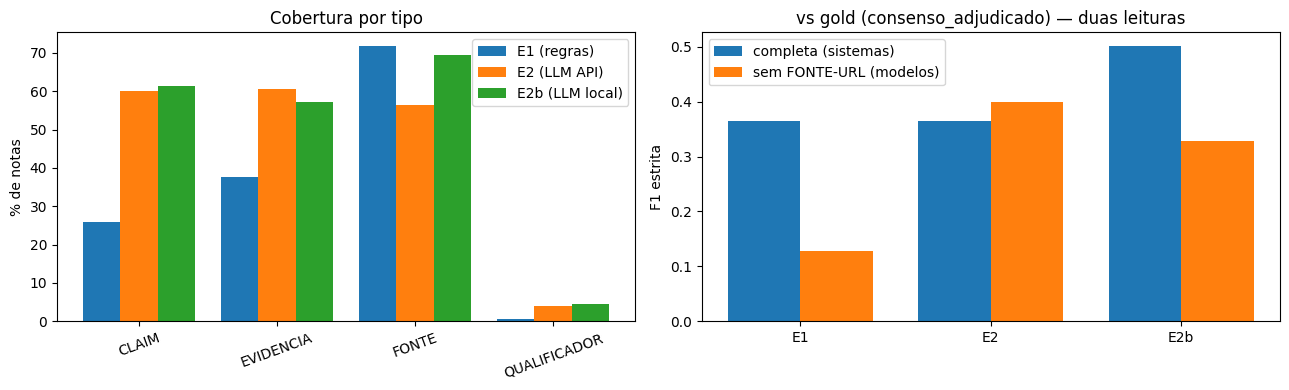

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(LABELS)); w = 0.27
axes[0].bar(x - w, cobertura_df["cob_E1_%"], w, label="E1 (regras)")
axes[0].bar(x, cobertura_df["cob_E2_%"], w, label="E2 (LLM API)")
if "cob_E2b_%" in cobertura_df.columns:
    axes[0].bar(x + w, cobertura_df["cob_E2b_%"], w, label="E2b (LLM local)")
axes[0].set_xticks(x); axes[0].set_xticklabels(LABELS, rotation=20)
axes[0].set_ylabel("% de notas"); axes[0].set_title("Cobertura por tipo"); axes[0].legend()

sub = vsgold_df.pivot(index="estrategia", columns="leitura", values="F1_estrita")
sub = sub.reindex([n for n, _ in ESTRATEGIAS])
xx = np.arange(len(sub)); w2 = 0.38
axes[1].bar(xx - w2 / 2, sub["completa"], w2, label="completa (sistemas)")
axes[1].bar(xx + w2 / 2, sub["sem FONTE-URL"], w2, label="sem FONTE-URL (modelos)")
axes[1].set_xticks(xx); axes[1].set_xticklabels(sub.index)
axes[1].set_ylabel("F1 estrita")
axes[1].set_title(f"vs gold ({gold_label}) — duas leituras")
axes[1].legend()
plt.tight_layout(); plt.show()

## 16. Avaliação token-level (estilo seqeval, com *cross-check* da biblioteca)

**Como ler:** P/R/F1 por entidade BIO (fronteira de token **e** tipo), implementação
própria determinística **verificada contra a biblioteca `seqeval`** (modo estrito, esquema
IOB2) na própria célula. Na **matriz de confusão** (linha = humano, coluna = E2), valores
fora da diagonal em `O→TIPO` indicam **super-extração**; `TIPO→O` indica **omissão**.

In [21]:
def bio_entities(labels):
    ents = set(); i = 0
    while i < len(labels):
        if labels[i].startswith("B-"):
            t = labels[i][2:]; j = i + 1
            while j < len(labels) and labels[j] == f"I-{t}": j += 1
            ents.add((i, j, t)); i = j
        else: i += 1
    return ents

def entity_prf(gold_lists, pred_lists):
    tp = fp = fn = 0; per = {t: [0, 0, 0] for t in LABELS}
    for g, p in zip(gold_lists, pred_lists):
        ge, pe = bio_entities(g), bio_entities(p)
        tp += len(ge & pe); fp += len(pe - ge); fn += len(ge - pe)
        for t in LABELS:
            gt = {e for e in ge if e[2] == t}; pt = {e for e in pe if e[2] == t}
            per[t][0] += len(gt & pt); per[t][1] += len(pt - gt); per[t][2] += len(gt - pt)
    def prf(tp, fp, fn):
        P = tp / (tp + fp) if tp + fp else 0.0; R = tp / (tp + fn) if tp + fn else 0.0
        return P, R, (2 * P * R / (P + R) if P + R else 0.0)
    P, R, F = prf(tp, fp, fn)
    rows = [{"escopo": "micro", "P": round(P, 3), "R": round(R, 3), "F1": round(F, 3)}]
    for t in LABELS:
        p, r, f = prf(*per[t]); rows.append({"escopo": t, "P": round(p, 3), "R": round(r, 3), "F1": round(f, 3)})
    return pd.DataFrame(rows)

# cross-check: a implementacao manual deve coincidir com a biblioteca seqeval
try:
    from seqeval.metrics import f1_score as _seq_f1
    from seqeval.scheme import IOB2 as _IOB2
    _HAS_SEQEVAL = True
except ImportError:
    _HAS_SEQEVAL = False
    print("seqeval ausente; cross-check pulado (instale na celula de dependencias).")

def crosscheck_seqeval(gold_lists, pred_lists, rotulo):
    if not _HAS_SEQEVAL:
        return
    manual = float(entity_prf(gold_lists, pred_lists).iloc[0]["F1"])
    lib = float(_seq_f1(gold_lists, pred_lists, mode="strict", scheme=_IOB2))
    assert abs(manual - lib) < 5e-4, f"[{rotulo}] manual={manual:.4f} lib={lib:.4f}"
    print(f"cross-check seqeval [{rotulo}]: manual={manual:.3f} == lib={lib:.3f}  OK")

pairs = [(json.loads(a), json.loads(b)) for a, b in zip(df_bio["e1_span_bio_json"], df_bio["e2_span_bio_json"])
         if isinstance(a, str) and isinstance(b, str)]
if pairs:
    print("Token-level (entity) — E1×E2, corpus inteiro:")
    display(entity_prf([x[0] for x in pairs], [x[1] for x in pairs]))
    crosscheck_seqeval([x[0] for x in pairs], [x[1] for x in pairs], "E1xE2")

hum_mask = df_bio["humano_span_bio_json"].notna()
if hum_mask.any():
    sub = df_bio[hum_mask]
    h = [json.loads(v) for v in sub["humano_span_bio_json"]]
    for rotulo, col in [("E1", "e1_span_bio_json"), ("E2", "e2_span_bio_json"), ("E2b", "e2b_span_bio_json")]:
        if col not in sub.columns or sub[col].isna().all():
            continue
        p = [json.loads(v) if isinstance(v, str) else ["O"] * len(hh) for v, hh in zip(sub[col], h)]
        print(f"Token-level (entity) — {rotulo} vs humano:"); display(entity_prf(h, p))
        crosscheck_seqeval(h, p, f"{rotulo} vs humano")
    e2 = [json.loads(v) for v in sub["e2_span_bio_json"]]
    cats = ["O"] + LABELS
    conf = pd.DataFrame(0, index=cats, columns=cats)
    for hl, el in zip(h, e2):
        for a, b in zip(hl, el): conf.loc[a.split("-")[-1], b.split("-")[-1]] += 1
    print("Matriz de confusao por token (linha=humano, coluna=E2):"); display(conf)

Token-level (entity) — E1×E2, corpus inteiro:


,escopo,P,R,F1
0,micro,0.265,0.377,0.311
1,CLAIM,0.015,0.045,0.023
2,EVIDENCIA,0.004,0.008,0.005
3,FONTE,0.780,0.624,0.693
4,QUALIFICADOR,0.013,0.100,0.023


cross-check seqeval [E1xE2]: manual=0.311 == lib=0.311  OK
Token-level (entity) — E1 vs humano:


,escopo,P,R,F1
0,micro,0.485,0.366,0.417
1,CLAIM,0.067,0.032,0.043
2,EVIDENCIA,0.000,0.000,0.000
3,FONTE,0.711,0.659,0.684
4,QUALIFICADOR,0.000,0.000,0.000


cross-check seqeval [E1 vs humano]: manual=0.417 == lib=0.417  OK

...

cross-check seqeval [E2 vs humano]: manual=0.358 == lib=0.358  OK
Token-level (entity) — E2b vs humano:


,escopo,P,R,F1
0,micro,0.551,0.652,0.597
1,CLAIM,0.314,0.516,0.390
2,EVIDENCIA,0.300,0.309,0.304
3,FONTE,0.784,0.886,0.832
4,QUALIFICADOR,0.000,0.000,0.000


cross-check seqeval [E2b vs humano]: manual=0.597 == lib=0.597  OK


Matriz de confusao por token (linha=humano, coluna=E2):


,O,CLAIM,EVIDENCIA,FONTE,QUALIFICADOR
O,816,183,197,29,16
CLAIM,41,233,39,0,0
EVIDENCIA,364,62,710,14,2
FONTE,125,2,2,58,0
QUALIFICADOR,10,0,0,0,0


**Leitura.** A matriz de confusão revela *como* o E2 erra: ele **super-extrai** — marca
como CLAIM/EVIDÊNCIA trechos que o humano deixou em `O` — e às vezes **omite evidência**
(EVIDÊNCIA→`O`). As fronteiras de **FONTE** são imprecisas (recall alto, precisão baixa: pega
a fonte mas erra os limites). **QUALIFICADOR** tem exemplos demais escassos para conclusões.

## 17. §4.6 — Análises complementares

A **triangulação** (17.1) fecha a parte quantitativa. As demais análises complementares da
§4.6 — **assinatura léxica por tipo** (Dunning), **lente de entidade × papel** e o **perfil
granular por entidade** (palavras distintivas por classe gramatical) — são exploratórias e
ficam melhor navegáveis: migraram para o **explorador interativo** (17.2), construído sobre a
camada BIO e o corpus de entidades.

### 17.1 Triangulação

**Como ler:** comparamos o acordo humano×estratégia (κ char-level) com a fidelidade TF-IDF
(§4.2). Se a estratégia mais próxima do humano também for a mais fiel ao tweet, a métrica
automática está calibrada com o julgamento humano.

In [22]:
if gold:
    rows = []
    for nome, col in ESTRATEGIAS:
        ks = []
        for nid in annotated_ids:
            txt = text_by_id.get(nid) or ""
            g = _to_S(gold[nid])
            p = spans_from_cell(df.loc[df["noteId"] == nid, col].iloc[0])
            if txt: ks.append(cohen_kappa_chars(txt, g, p))
        rows.append({"estrategia": nome, "kappa_vs_gold": round(float(np.nanmean(ks)), 3) if ks else float("nan")})
    display(pd.DataFrame(rows))

,estrategia,kappa_vs_gold
0,E1,0.438
1,E2,0.365
2,E2b,0.593


**Leitura.** A estratégia mais próxima do humano (κ vs gold) é a mesma que ancora mais o
CLAIM no tweet (§4.2): os dois sinais apontam na mesma direção, o que dá alguma validade
convergente à métrica TF-IDF como proxy barato do julgamento humano.

### 17.2 Explorador interativo

As análises léxicas e de entidade são mais ricas navegáveis. O explorador estático — spans
coloridos por nota (com o raciocínio do E2), **perfil por entidade** com palavras distintivas
por classe gramatical, **lente entidade × papel** e **painel de achados** — está publicado no
Netlify e embutido abaixo. Código e build em `explorador-argumentos/`.

In [23]:
from IPython.display import IFrame
IFrame("https://explorador-argumentos.netlify.app/", width="100%", height=720)

## 18. Camada sintática (POS · lema · dependência)

O Notebook 1 já rodou o parser completo (`pt_core_news_md`) para extrair os spans do E1 — mas
**só os spans foram persistidos**; o parse (POS, lema, relação de dependência) foi intermediário
e descartado. Aqui re-rodamos o **mesmo modelo** e **salvamos** essa camada no dataset final, para
análises sintáticas reprodutíveis — assinatura léxica lematizada e a leitura de **agência
sujeito × objeto** (via `deprel`) — sem precisar re-taggear.

In [24]:
import spacy
try:
    nlp_full = spacy.load("pt_core_news_md")
except OSError:
    from spacy.cli import download as _spacy_dl
    _spacy_dl("pt_core_news_md"); nlp_full = spacy.load("pt_core_news_md")

def _parse_nota(doc):
    return [{"i": t.i, "form": t.text, "lemma": t.lemma_, "upos": t.pos_,
             "deprel": t.dep_, "head": t.head.i, "start": t.idx, "end": t.idx + len(t.text)}
            for t in doc if not t.is_space]

_sint = []
for doc in tqdm(nlp_full.pipe(df_bio[TEXT_COL].fillna("").astype(str), batch_size=64),
                total=len(df_bio), desc="Sintaxe (pt_core_news_md)"):
    _sint.append(json.dumps(_parse_nota(doc), ensure_ascii=False))
df_bio["sintaxe_json"] = _sint
print("sintaxe_json em", int(df_bio["sintaxe_json"].notna().sum()),
      "notas — POS/lema/deprel persistidos no dataset final")

Sintaxe (pt_core_news_md):   0%|          | 0/1901 [00:00<?, ?it/s]

Sintaxe (pt_core_news_md):   0%|          | 1/1901 [00:01<1:01:26,  1.94s/it]

Sintaxe (pt_core_news_md):   3%|▎         | 65/1901 [00:03<01:32, 19.94it/s] 

Sintaxe (pt_core_news_md):   7%|▋         | 129/1901 [00:05<01:07, 26.22it/s]

Sintaxe (pt_core_news_md):  10%|█         | 193/1901 [00:07<00:56, 30.04it/s]

...

Sintaxe (pt_core_news_md):  91%|█████████ | 1729/1901 [00:49<00:04, 36.57it/s]

Sintaxe (pt_core_news_md):  94%|█████████▍| 1793/1901 [00:51<00:02, 39.62it/s]

Sintaxe (pt_core_news_md):  98%|█████████▊| 1857/1901 [00:52<00:01, 40.15it/s]

Sintaxe (pt_core_news_md): 100%|██████████| 1901/1901 [00:52<00:00, 35.99it/s]

sintaxe_json em 1901 notas — POS/lema/deprel persistidos no dataset final


## 19. Dataset final e artefatos

O `df_bio` carrega **tudo**: spans E1/E2, gold humano (consenso, quando há 2 anotadores), as
camadas BIO das três fontes, a **camada sintática** (`sintaxe_json`: POS/lema/dependência, §18),
as métricas e os metadados de reprodução. Salvamos o parquet final + um `sintaxe.json` e CSVs
auxiliares. É o pacote para subir no repositório do curso.

In [25]:
df_bio.to_parquet(FINAL_DATASET_PATH, engine="pyarrow", index=False)
bio_report.to_csv(OUT_DIR / "relatorio_bio_projection.csv", index=False)
if not bio_problems.empty:
    bio_problems.to_csv(OUT_DIR / "problemas_bio_projection.csv", index=False)
resumo.to_csv(OUT_DIR / "metricas_4_1_cortes.csv", index=False)
pres_df.to_csv(OUT_DIR / "metricas_4_1_presenca.csv", index=False)
if vsgold_df is not None:
    vsgold_df.to_csv(OUT_DIR / "metricas_4_5_vs_gold.csv", index=False)
    sens_df.to_csv(OUT_DIR / "metricas_4_5_sensibilidade.csv", index=False)
    portipo_df.to_csv(OUT_DIR / "metricas_4_5_por_tipo.csv", index=False)
if kappa_inter_df is not None:
    kappa_inter_df.to_csv(OUT_DIR / "kappa_inter_anotador.csv", index=False)
if "sintaxe_json" in df_bio.columns:
    sint_map = {str(nid): json.loads(s) for nid, s in zip(df_bio["noteId"], df_bio["sintaxe_json"]) if isinstance(s, str)}
    (OUT_DIR / "sintaxe.json").write_text(json.dumps(sint_map, ensure_ascii=False), encoding="utf-8")
    print("sintaxe.json:", len(sint_map), "notas (POS/lema/deprel)")

print("Dataset final:", FINAL_DATASET_PATH, "| linhas:", len(df_bio))
print("gold humano:", gold_label, "|", len(annotated_ids), "notas")

sintaxe.json: 1901 notas (POS/lema/deprel)
Dataset final: outputs\dataset_anotado_final_com_bio.parquet | linhas: 1901
gold humano: consenso_adjudicado | 60 notas


## 20. Download no Colab (opcional)

In [26]:
# from google.colab import files
# files.download(str(FINAL_DATASET_PATH))

## Síntese final

As leituras por seção convergem: **E1, E2 e E2b divergem onde a argumentação exige
interpretação** (CLAIM, QUALIFICADOR) e convergem no que é lexical (FONTE — em parte por
**infraestrutura compartilhada de URL**, agora declarada e decomposta). A avaliação contra
o gold é **multi-gold e em duas leituras**: a leitura *completa* compara sistemas; a *sem
FONTE-URL* compara modelos sobre o conteúdo decidido — e a sensibilidade entre réguas
humanas é, por si, um resultado sobre a natureza da tarefa (fronteiras fluidas mesmo entre
anotadores; κ inter-anotador na §5). O E2b mostra o custo/benefício de trocar a API
proprietária por um modelo aberto local. Os números consolidados desta execução alimentam
o relatório e o explorador.

## Próximos passos

- **Fechamento da adjudicação:** revisão cruzada do segundo anotador sobre o parecer
  individual (`apps/adjudicador`, rodada `revisao_cruzada` → `fechamento`); ao exportar o
  novo JSON, basta atualizar `CONSENSUS_JSON_RELPATH` e re-executar.
- **Notebook 3 (destilação):** re-executar com o dataset/gold desta execução; opcional:
  treinar o melhor aluno também com o *silver* do E2b (professor aberto).
- **Relatório:** atualizar tabelas com os números desta execução (multi-gold, duas
  leituras, E2b, κ inter-anotador nas duas agregações).